In [1]:
%run GseConsole.py -ipython boot dpu_software/SOPHI_DPU.bin
%autocall 1

from ipywidgets import *
from IPython.display import display
from IPython.display import clear_output
    
def button_click(_):
    gse('config bitfiles/preproc.bit 2')

clear_output(True)
container = Box()
msg_area = HTML()

button = Button(description='Configure FPGA')
button.on_click(button_click)

container.children = [button, msg_area]
display(container)
    
def t_hand(s, fmt='i'):
    color = 'black'
    if fmt == 'i':
        color = 'darkblue'
    elif fmt == 's':
        color = 'darkgreen'
    elif fmt == 'e':
        color = 'darkred'
    elif fmt == 'w':
        color = 'darkorange'
    msg_area.value += '<br><tt style="color:' + color + ';">' + s + '</tt>'
    
interpreter.spw.print_handler = t_hand
    

DPU will boot into: dpu_software/SOPHI_DPU.bin


Automatic calling is: Smart


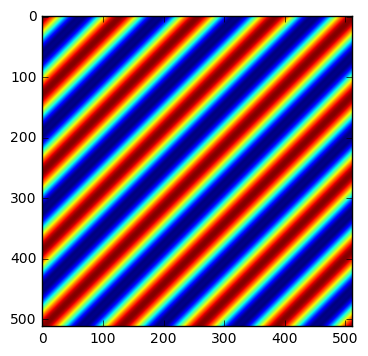

In [2]:
from TestVector import *
testvector = TestVector()
data = testvector.image('testdata/sin8d.gif')
interpreter.preproc.store_direct(data, 0x00000)

In [ ]:
testvector = TestVector()
data = testvector.image('testdata/QM2.png')
interpreter.preproc.store_direct(data, 0x40000)

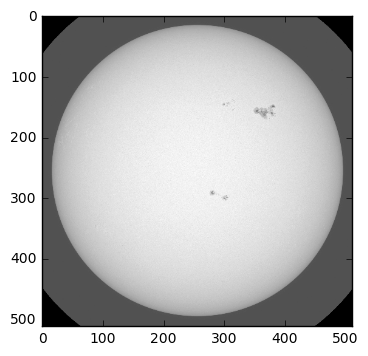

In [3]:
testvector = TestVector()
data = testvector.fits('testdata/FDT_Nom.fits', [512, 512])
interpreter.preproc.store_direct(data, 0x40000)

In [5]:
interpreter.preproc.mult(0, 0x40000, 0x80000, 0x40000)

In [6]:
gse 'preproc_load 0x80000 0x40000'

------> gse('preproc_load 0x80000 0x40000')


------> gse('cimage')


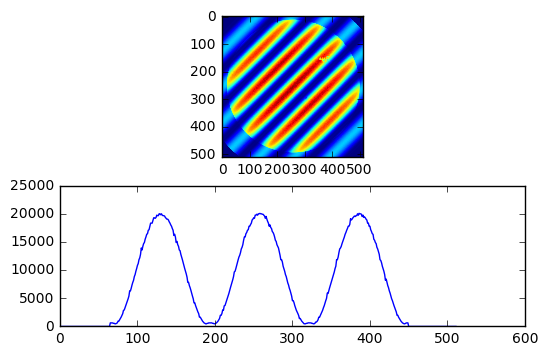

In [7]:
gse 'cimage'